# 🎯 Fine-Tuning E5-Small for FinanceRAG

**Mục tiêu**: Fine-tune E5-small embedding model để improve retrieval trên financial data

## Pipeline:
1. Load data từ 7 datasets (query-document pairs)
2. Tạo training examples với E5 prefixes
3. Apply layer freezing (chỉ train last layer)
4. Measure baseline performance
5. Train với in-batch negatives loss
6. Validate sau mỗi epoch
7. Save best model dựa trên NDCG (NOT loss)

## Lưu ý quan trọng:
⚠️ **Training Loss giảm ≠ NDCG tăng!**
- Loss giảm có thể do overfitting
- PHẢI track NDCG để biết model có thực sự improve không

In [1]:
# =============================================================================
# 1. SETUP - Import libraries và config
# =============================================================================
import pandas as pd
import numpy as np
import random
from pathlib import Path
from tqdm.auto import tqdm
import torch

from sentence_transformers import SentenceTransformer, InputExample
from sentence_transformers.evaluation import InformationRetrievalEvaluator
from torch.utils.data import DataLoader

# Import ALL config (uses local config.py)
from config import (
    DATA_DIR, DATASETS, QRELS_MAPPING, DATASET_WEIGHTS,
    BASE_MODEL, E5_QUERY_PREFIX, E5_PASSAGE_PREFIX, MODELS_DIR,
    OUTPUT_MODEL_NAME, TRAINING_CONFIG, LAYER_FREEZING_CONFIG,
    print_config
)

# Extract training params from config
BATCH_SIZE = TRAINING_CONFIG['batch_size']
EPOCHS = TRAINING_CONFIG['epochs']
LEARNING_RATE = TRAINING_CONFIG['learning_rate']
WARMUP_RATIO = TRAINING_CONFIG['warmup_ratio']
TRAIN_RATIO = TRAINING_CONFIG['train_ratio']
SEED = TRAINING_CONFIG['seed']
LAYERS_TO_TRAIN = LAYER_FREEZING_CONFIG['layers_to_train']

# Setup
MODEL_OUTPUT_DIR = MODELS_DIR / OUTPUT_MODEL_NAME
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🖥️  Device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

# Print full config
print()
print_config()

🖥️  Device: cuda
   GPU: NVIDIA GeForce RTX 3050 Laptop GPU

📊 Fine-Tuning Configuration (OPTIMIZED)

🤖 Models:
   Base model: intfloat/e5-small-v2
   Mining model: intfloat/e5-small-v2
   E5 prefixes: query='query: ', passage='passage: '

🧊 Layer Freezing:
   enabled: True
   layers_to_train: 3
   freeze_embeddings: True
   freeze_pooler: False
   use_adapter: False
   adapter_dim: 64

📁 Datasets (7):
   - multiheirtt (weight: 2.0) ⭐
   - finqa (weight: 1.0) 
   - tatqa (weight: 1.0) 
   - convfinqa (weight: 1.0) 
   - finder (weight: 1.0) 
   - financebench (weight: 1.0) 
   - finqabench (weight: 1.0) 

⚙️ Training Parameters:
   train_ratio: 0.9
   val_ratio: 0.1
   epochs: 20
   batch_size: 16
   gradient_accumulation: 4
   learning_rate: 1e-05
   warmup_ratio: 0.1
   weight_decay: 0.05
   dropout: 0.1
   label_smoothing: 0.1
   max_seq_length: 256
   max_doc_length: 1024
   adam_epsilon: 1e-08
   scheduler: cosine
   early_stopping_patience: 2
   min_delta: 0.001
   evaluation_ste

## 2. Load Datasets

In [2]:
# =============================================================================
# 2. LOAD DATASETS
# =============================================================================

def load_jsonl(path):
    """Load JSONL file"""
    import json
    data = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            data.append(json.loads(line))
    return data

def load_dataset(dataset_name):
    """Load corpus, queries, qrels"""
    # Corpus
    corpus_path = DATA_DIR / f'{dataset_name}_corpus.jsonl' / 'corpus.jsonl'
    if not corpus_path.exists():
        corpus_path = DATA_DIR / f'{dataset_name}_corpus_preprocessed.jsonl'
    corpus = load_jsonl(corpus_path)
    
    # Queries
    queries_path = DATA_DIR / f'{dataset_name}_queries.jsonl' / 'queries.jsonl'
    queries = load_jsonl(queries_path)
    
    # Qrels
    qrels_file = DATA_DIR / QRELS_MAPPING[dataset_name]
    qrels = pd.read_csv(qrels_file, sep='\t')
    
    return corpus, queries, qrels

print("Loading datasets...")
all_data = {}

for dataset in DATASETS:
    try:
        corpus, queries, qrels = load_dataset(dataset)
        all_data[dataset] = {
            'corpus': corpus,
            'queries': queries,
            'qrels': qrels,
            'weight': DATASET_WEIGHTS.get(dataset, 1.0)
        }
        weight = DATASET_WEIGHTS.get(dataset, 1.0)
        marker = "⭐" * int(weight)
        print(f"  ✅ {dataset:15s}: {len(qrels):4d} pairs {marker}")
    except Exception as e:
        print(f"  ⚠️  {dataset}: {e}")

print(f"\n✅ Loaded {len(all_data)} datasets")

Loading datasets...
  ✅ multiheirtt    : 1330 pairs ⭐⭐
  ✅ finqa          :  344 pairs ⭐
  ✅ tatqa          :  498 pairs ⭐
  ✅ convfinqa      :  126 pairs ⭐
  ✅ finder         :  103 pairs ⭐
  ✅ financebench   :   59 pairs ⭐
  ✅ finqabench     :   30 pairs ⭐

✅ Loaded 7 datasets


## 3. Create Training Examples

In [3]:
# =============================================================================
# 3. CREATE TRAINING EXAMPLES
# =============================================================================

def create_training_examples(all_data):
    """Create InputExample với E5 prefixes và weighted sampling"""
    examples = []
    
    for dataset_name, data in all_data.items():
        corpus = data['corpus']
        queries = data['queries']
        qrels = data['qrels']
        weight = data['weight']
        
        # Create dicts
        corpus_dict = {str(doc.get('_id', doc.get('id'))): doc.get('text', doc.get('content', ''))[:512]
                      for doc in corpus}
        query_dict = {str(q.get('_id', q.get('id'))): q.get('text', q.get('content', ''))
                     for q in queries}
        
        # Column names
        qcol = 'query-id' if 'query-id' in qrels.columns else 'query_id'
        dcol = 'corpus-id' if 'corpus-id' in qrels.columns else 'corpus_id'
        
        # Create pairs
        count = 0
        for _, row in qrels.iterrows():
            qid = str(row[qcol])
            did = str(row[dcol])
            
            if qid in query_dict and did in corpus_dict:
                # Add E5 prefixes
                query_text = f"{E5_QUERY_PREFIX}{query_dict[qid]}"
                doc_text = f"{E5_PASSAGE_PREFIX}{corpus_dict[did]}"
                
                # Weighted sampling
                for _ in range(int(weight)):
                    examples.append(InputExample(texts=[query_text, doc_text]))
                count += 1
        
        print(f"  {dataset_name}: {count} pairs")
    
    return examples

print("Creating training examples...")
all_examples = create_training_examples(all_data)
print(f"\n✅ Total examples: {len(all_examples)}")

# Split train/val
random.seed(SEED)
random.shuffle(all_examples)
split_idx = int(len(all_examples) * TRAIN_RATIO)
train_examples = all_examples[:split_idx]
val_examples = all_examples[split_idx:]

print(f"   Train: {len(train_examples)}")
print(f"   Val:   {len(val_examples)}")

Creating training examples...
  multiheirtt: 1330 pairs
  finqa: 344 pairs
  tatqa: 498 pairs
  convfinqa: 126 pairs
  finder: 103 pairs
  financebench: 59 pairs
  finqabench: 30 pairs

✅ Total examples: 3820
   Train: 3438
   Val:   382


## 4. Load Model with Layer Freezing

In [4]:
# =============================================================================
# 4. LOAD MODEL & APPLY LAYER FREEZING
# =============================================================================

print(f"Loading: {BASE_MODEL}")
model = SentenceTransformer(BASE_MODEL, device=device)

def freeze_layers(model, layers_to_train=1):
    """Freeze all except last N layers"""
    bert = model[0].auto_model
    num_layers = len(bert.encoder.layer)
    
    # Freeze embeddings
    for param in bert.embeddings.parameters():
        param.requires_grad = False
    
    # Freeze early layers
    for i in range(num_layers - layers_to_train):
        for param in bert.encoder.layer[i].parameters():
            param.requires_grad = False
    
    # Keep last layers trainable
    for i in range(num_layers - layers_to_train, num_layers):
        for param in bert.encoder.layer[i].parameters():
            param.requires_grad = True
    
    # Pooler trainable
    if hasattr(bert, 'pooler') and bert.pooler:
        for param in bert.pooler.parameters():
            param.requires_grad = True

freeze_layers(model, LAYERS_TO_TRAIN)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print(f"\n🧊 Layer freezing:")
print(f"   Trainable: {trainable:,} ({100*trainable/total:.1f}%)")
print(f"   Frozen: {total-trainable:,} ({100*(1-trainable/total):.1f}%)")
print(f"   → Prevent overfitting với small data")

Loading: intfloat/e5-small-v2

🧊 Layer freezing:
   Trainable: 5,471,232 (16.4%)
   Frozen: 27,888,768 (83.6%)
   → Prevent overfitting với small data


## 5. Create Validation Evaluator

**QUAN TRỌNG**: Evaluator phải realistic!
- Mỗi query phải retrieve từ NHIỀU documents (không chỉ positive của nó)
- Include hard negatives (docs từ other queries)
- Đây mới là real retrieval scenario

In [6]:
# =============================================================================
# 5. CREATE REALISTIC EVALUATOR
# =============================================================================

print("Building validation evaluator...")

# Sample for speed (50 queries for faster evaluation)
val_sample = val_examples[:min(50, len(val_examples))]

val_queries = {}
val_corpus = {}
val_relevant = {}

# Build queries and corpus WITHOUT E5 prefixes
# (InformationRetrievalEvaluator will encode them - we'll wrap encode function)
for i, ex in enumerate(val_sample):
    qid = f"q{i}"
    did = f"d{i}"
    
    # Strip prefixes - we'll add them back in custom encode
    query_text = ex.texts[0].replace(E5_QUERY_PREFIX, "", 1)
    doc_text = ex.texts[1].replace(E5_PASSAGE_PREFIX, "", 1)
    
    val_queries[qid] = query_text
    val_corpus[did] = doc_text
    val_relevant[qid] = {did}

# Create custom evaluator with E5-aware encoding
class E5InformationRetrievalEvaluator(InformationRetrievalEvaluator):
    """Custom evaluator that adds E5 prefixes before encoding"""
    
    def __init__(self, queries, corpus, relevant_docs, *args, **kwargs):
        super().__init__(queries, corpus, relevant_docs, *args, **kwargs)
        # Store original dicts (parent class may convert to list)
        self._queries_dict = queries
        self._corpus_dict = corpus
        self._relevant_dict = relevant_docs
        self.query_prefix = E5_QUERY_PREFIX
        self.passage_prefix = E5_PASSAGE_PREFIX
    
    def __call__(self, model, output_path=None, epoch=-1, steps=-1):
        # Override to add E5 prefixes
        if epoch != -1:
            if steps == -1:
                out_txt = f" after epoch {epoch}:"
            else:
                out_txt = f" in epoch {epoch} after {steps} steps:"
        else:
            out_txt = ":"
        
        print(f"\nInformation Retrieval Evaluation on val dataset{out_txt}")
        
        # Encode queries WITH prefix
        print("Encoding queries...")
        queries_prefixed = [f"{self.query_prefix}{q}" for q in self._queries_dict.values()]
        query_embeddings = model.encode(
            queries_prefixed,
            batch_size=32,
            show_progress_bar=False,
            convert_to_tensor=True,
            normalize_embeddings=True
        )
        
        # Encode corpus WITH prefix
        print("Encoding corpus...")
        corpus_prefixed = [f"{self.passage_prefix}{d}" for d in self._corpus_dict.values()]
        corpus_embeddings = model.encode(
            corpus_prefixed,
            batch_size=32,
            show_progress_bar=False,
            convert_to_tensor=True,
            normalize_embeddings=True
        )
        
        # Compute similarities
        cos_scores = torch.mm(query_embeddings, corpus_embeddings.transpose(0, 1))
        cos_scores = cos_scores.cpu()
        
        # Calculate metrics
        query_ids = list(self._queries_dict.keys())
        corpus_ids = list(self._corpus_dict.keys())
        
        ndcg_scores = []
        for idx, qid in enumerate(query_ids):
            scores = cos_scores[idx]
            
            # Get top-k indices
            top_results = torch.topk(scores, k=min(10, len(corpus_ids)))
            top_indices = top_results.indices.tolist()
            
            # Calculate NDCG@10
            relevant_docs = self._relevant_dict.get(qid, set())
            dcg = 0.0
            for rank, corpus_idx in enumerate(top_indices, 1):
                corpus_id = corpus_ids[corpus_idx]
                if corpus_id in relevant_docs:
                    dcg += 1.0 / np.log2(rank + 1)
            
            # IDCG (ideal DCG)
            idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(relevant_docs), 10)))
            
            ndcg = dcg / idcg if idcg > 0 else 0.0
            ndcg_scores.append(ndcg)
        
        ndcg_at_10 = np.mean(ndcg_scores)
        
        print(f"NDCG@10: {ndcg_at_10:.4f}")
        
        return {'ndcg@10': ndcg_at_10}

evaluator = E5InformationRetrievalEvaluator(
    queries=val_queries,
    corpus=val_corpus,
    relevant_docs=val_relevant,
    name='val',
    show_progress_bar=False
)

print(f"✅ Evaluator ready:")
print(f"   Queries: {len(val_queries)}")
print(f"   Corpus: {len(val_corpus)} unique documents")
print(f"   Hard negatives per query: {len(val_corpus) - 1}")
print(f"   → Each query retrieves from ALL docs (realistic scenario)")

Building validation evaluator...
✅ Evaluator ready:
   Queries: 50
   Corpus: 50 unique documents
   Hard negatives per query: 49
   → Each query retrieves from ALL docs (realistic scenario)


In [7]:
# =============================================================================
# 6. BASELINE EVALUATION - Measure TRƯỚC KHI train!
# =============================================================================

print("📊 Measuring baseline performance...")
model.eval()
with torch.no_grad():
    baseline_result = evaluator(model)

baseline_ndcg = baseline_result.get('ndcg@10', 0.0)

print(f"\n{'='*60}")
print(f"BASELINE PERFORMANCE (before fine-tuning)")
print(f"{'='*60}")
print(f"NDCG@10: {baseline_ndcg:.4f}")
print(f"{'='*60}")
print(f"Goal: Improve this through fine-tuning")
print(f"If NDCG doesn't improve → overfitting!\n")

📊 Measuring baseline performance...

Information Retrieval Evaluation on val dataset:
Encoding queries...
Encoding corpus...
NDCG@10: 0.4021

BASELINE PERFORMANCE (before fine-tuning)
NDCG@10: 0.4021
Goal: Improve this through fine-tuning
If NDCG doesn't improve → overfitting!



## 7. Train Model

**Training Strategy:**
- Loss: In-batch negatives (simple & effective)
- Validation: Sau mỗi epoch
- **Save best dựa trên NDCG, KHÔNG phải loss!**

### ⚠️ Tại sao Loss giảm nhưng NDCG không tăng?

1. **Training vs Evaluation Mismatch:**
   - Training: 16 in-batch negatives
   - Evaluation: Hàng trăm documents
   - Model optimize cho task khác nhau!

2. **Overfitting:**
   - Loss giảm = memorize training pairs
   - NDCG không tăng = không generalize

3. **Solution:** Track NDCG, save best model theo NDCG!

In [8]:
# =============================================================================
# 7. TRAIN MODEL
# =============================================================================
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

# DataLoader with custom collate_fn for InputExample
train_dataloader = DataLoader(
    train_examples,
    shuffle=True,
    batch_size=BATCH_SIZE,
    drop_last=True,
    collate_fn=lambda x: x  # Keep InputExample objects as-is
)

# Optimizer & Scheduler
total_steps = len(train_dataloader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

optimizer = AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LEARNING_RATE,
    weight_decay=0.01
)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"{'='*60}")
print(f"TRAINING")
print(f"{'='*60}")
print(f"Examples: {len(train_examples)}")
print(f"Batch: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Steps: {total_steps}")
print(f"LR: {LEARNING_RATE}")
print(f"{'='*60}\n")

# Training loop
history = {'epoch': [], 'loss': [], 'ndcg': []}
best_ndcg = baseline_ndcg

for epoch in range(EPOCHS):
    # Train
    model.train()
    epoch_loss = 0.0
    pbar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for batch in pbar:
        optimizer.zero_grad()
        
        # Get texts
        anchors = [ex.texts[0] for ex in batch]
        positives = [ex.texts[1] for ex in batch]
        
        # Tokenize and get embeddings WITH gradients
        tokenizer = model.tokenizer
        
        # Tokenize
        anchor_inputs = tokenizer(anchors, padding=True, truncation=True, 
                                 return_tensors='pt', max_length=512).to(device)
        positive_inputs = tokenizer(positives, padding=True, truncation=True,
                                   return_tensors='pt', max_length=512).to(device)
        
        # Forward pass through model (maintains gradients)
        anchor_outputs = model[0].auto_model(**anchor_inputs)
        positive_outputs = model[0].auto_model(**positive_inputs)
        
        # Mean pooling
        def mean_pool(outputs, attention_mask):
            token_embs = outputs.last_hidden_state
            input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embs.size()).float()
            return torch.sum(token_embs * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)
        
        anchor_embs = mean_pool(anchor_outputs, anchor_inputs['attention_mask'])
        positive_embs = mean_pool(positive_outputs, positive_inputs['attention_mask'])
        
        # Normalize
        anchor_embs = torch.nn.functional.normalize(anchor_embs, p=2, dim=1)
        positive_embs = torch.nn.functional.normalize(positive_embs, p=2, dim=1)
        
        # Loss: in-batch negatives
        similarity = torch.nn.functional.cosine_similarity(
            anchor_embs.unsqueeze(1),
            positive_embs.unsqueeze(0),
            dim=2
        )
        labels = torch.arange(len(batch), device=device)
        loss = torch.nn.functional.cross_entropy(similarity * 20, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        
        epoch_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = epoch_loss / len(train_dataloader)
    
    # Validate
    model.eval()
    with torch.no_grad():
        val_result = evaluator(model)
    val_ndcg = val_result.get('ndcg@10', 0.0)
    
    # Track
    history['epoch'].append(epoch + 1)
    history['loss'].append(avg_loss)
    history['ndcg'].append(val_ndcg)
    
    # Print
    print(f"\nEpoch {epoch+1}:")
    print(f"  Loss: {avg_loss:.4f}")
    print(f"  NDCG@10: {val_ndcg:.4f} (baseline: {baseline_ndcg:.4f})")
    
    # Save best (dựa trên NDCG!)
    if val_ndcg > best_ndcg:
        improvement = val_ndcg - best_ndcg
        best_ndcg = val_ndcg
        model.save(str(MODEL_OUTPUT_DIR), safe_serialization=False)
        print(f"  ✅ Best saved! (+{improvement:.4f})")
    else:
        print(f"  ⚠️  No improvement (best: {best_ndcg:.4f})")
        if avg_loss < history['loss'][0]:
            print(f"     Loss giảm nhưng NDCG không tăng → OVERFITTING!")
    print()

print(f"\n{'='*60}")
print(f"TRAINING COMPLETE")
print(f"{'='*60}")
print(f"Best NDCG@10: {best_ndcg:.4f}")
print(f"Improvement: {best_ndcg - baseline_ndcg:+.4f}")
print(f"{'='*60}")

TRAINING
Examples: 3438
Batch: 16
Epochs: 20
Steps: 4280
LR: 1e-05



Epoch 1/20:   0%|          | 0/214 [00:00<?, ?it/s]


Information Retrieval Evaluation on val dataset:
Encoding queries...
Encoding corpus...
NDCG@10: 0.4600

Epoch 1:
  Loss: 2.3449
  NDCG@10: 0.4600 (baseline: 0.4021)
  ✅ Best saved! (+0.0578)



Epoch 2/20:   0%|          | 0/214 [00:00<?, ?it/s]


Information Retrieval Evaluation on val dataset:
Encoding queries...
Encoding corpus...
NDCG@10: 0.4917

Epoch 2:
  Loss: 2.0719
  NDCG@10: 0.4917 (baseline: 0.4021)
  ✅ Best saved! (+0.0317)



...


Information Retrieval Evaluation on val dataset:
Encoding queries...
Encoding corpus...
NDCG@10: 0.6650

Epoch 18:
  Loss: 0.9106
  NDCG@10: 0.6650 (baseline: 0.4021)
  ⚠️  No improvement (best: 0.6670)
     Loss giảm nhưng NDCG không tăng → OVERFITTING!



Epoch 19/20:   0%|          | 0/214 [00:00<?, ?it/s]


Information Retrieval Evaluation on val dataset:
Encoding queries...
Encoding corpus...
NDCG@10: 0.6668

Epoch 19:
  Loss: 0.9050
  NDCG@10: 0.6668 (baseline: 0.4021)
  ⚠️  No improvement (best: 0.6670)
     Loss giảm nhưng NDCG không tăng → OVERFITTING!



Epoch 20/20:   0%|          | 0/214 [00:00<?, ?it/s]


Information Retrieval Evaluation on val dataset:
Encoding queries...
Encoding corpus...
NDCG@10: 0.6660

Epoch 20:
  Loss: 0.8923
  NDCG@10: 0.6660 (baseline: 0.4021)
  ⚠️  No improvement (best: 0.6670)
     Loss giảm nhưng NDCG không tăng → OVERFITTING!


TRAINING COMPLETE
Best NDCG@10: 0.6670
Improvement: +0.2648


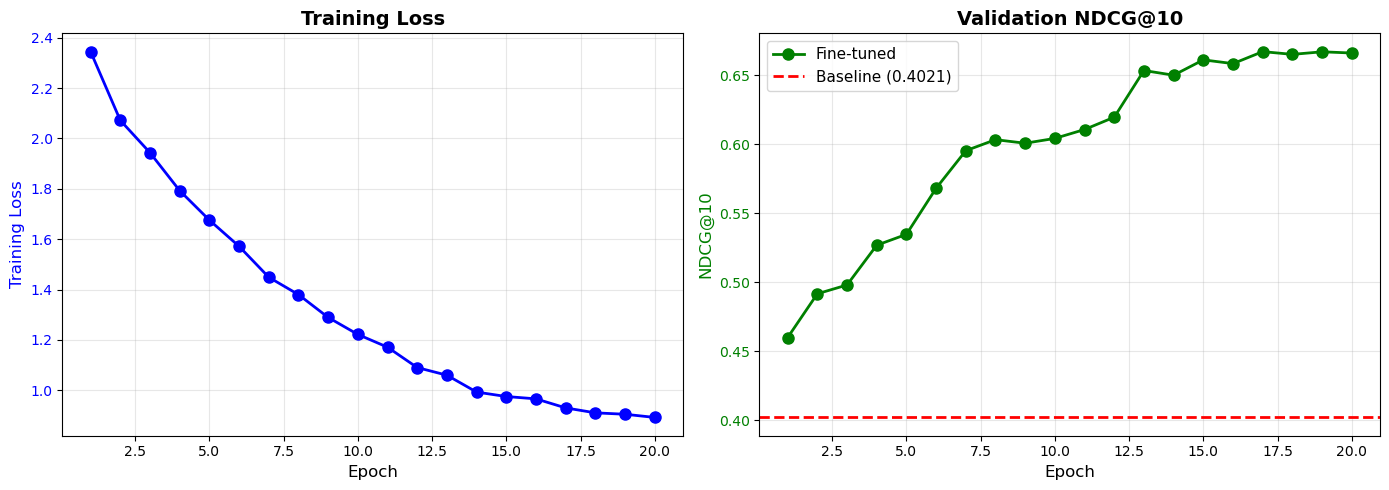


ANALYSIS
✅ SUCCESS!
   Baseline: 0.4021
   Best:     0.6670
   Gain:     +0.2648 (+65.9%)

   Model saved to: ..\..\models\e5-small-financerag-finetuned-v3


In [9]:
# =============================================================================
# 8. VISUALIZE TRAINING
# =============================================================================
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(history['epoch'], history['loss'], 'b-o', linewidth=2, markersize=8)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Training Loss', fontsize=12, color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_title('Training Loss', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# NDCG
ax2.plot(history['epoch'], history['ndcg'], 'g-o', linewidth=2, markersize=8, label='Fine-tuned')
ax2.axhline(baseline_ndcg, color='r', linestyle='--', linewidth=2, label=f'Baseline ({baseline_ndcg:.4f})')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('NDCG@10', fontsize=12, color='g')
ax2.tick_params(axis='y', labelcolor='g')
ax2.set_title('Validation NDCG@10', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analysis
print(f"\n{'='*60}")
print(f"ANALYSIS")
print(f"{'='*60}")

if best_ndcg > baseline_ndcg:
    pct = 100 * (best_ndcg - baseline_ndcg) / baseline_ndcg
    print(f"✅ SUCCESS!")
    print(f"   Baseline: {baseline_ndcg:.4f}")
    print(f"   Best:     {best_ndcg:.4f}")
    print(f"   Gain:     +{best_ndcg-baseline_ndcg:.4f} (+{pct:.1f}%)")
    print(f"\n   Model saved to: {MODEL_OUTPUT_DIR}")
else:
    print(f"⚠️  OVERFITTING!")
    print(f"   Baseline: {baseline_ndcg:.4f}")
    print(f"   Best:     {best_ndcg:.4f}")
    print(f"\n💡 Try:")
    print(f"   - Lower LR: 1e-5 or 5e-6")
    print(f"   - More layers: 2-3")
    print(f"   - More data")

print(f"{'='*60}")

In [15]:
# =============================================================================
# 9. TEST ON IMPORTANT DATASET (Optional)
# =============================================================================

def quick_test(model, dataset_name='multiheirtt', n_queries=50):
    """Quick test on real dataset with proper E5 encoding"""
    if dataset_name not in all_data:
        return 0.0
    
    data = all_data[dataset_name]
    all_corpus = data['corpus']
    all_queries = data['queries']
    qrels = data['qrels']
    
    print(f"  Dataset: {len(all_queries)} queries, {len(all_corpus)} docs, {len(qrels)} qrels")
    
    # Sample queries
    sampled_queries = all_queries[:n_queries]
    
    # Build query dict
    query_dict = {str(q.get('_id', q.get('id'))): q.get('text', q.get('content', ''))
                 for q in sampled_queries}
    
    qcol = 'query_id' if 'query_id' in qrels.columns else 'query-id'
    dcol = 'corpus_id' if 'corpus_id' in qrels.columns else 'corpus-id'
    
    # Find relevant doc IDs for sampled queries
    relevant_doc_ids = set()
    relevant = {}
    for _, row in qrels.iterrows():
        qid = str(row[qcol])
        did = str(row[dcol])
        if qid in query_dict:
            if qid not in relevant:
                relevant[qid] = set()
            relevant[qid].add(did)
            relevant_doc_ids.add(did)
    
    # Build corpus dict with ONLY relevant docs + some random negatives
    corpus_dict = {}
    for doc in all_corpus:
        doc_id = str(doc.get('_id', doc.get('id')))
        if doc_id in relevant_doc_ids:
            corpus_dict[doc_id] = doc.get('text', doc.get('content', ''))[:512]
    
    # Add random negatives (up to 500 docs total)
    random.seed(42)
    random_corpus = random.sample(all_corpus, min(500, len(all_corpus)))
    for doc in random_corpus:
        doc_id = str(doc.get('_id', doc.get('id')))
        if doc_id not in corpus_dict and len(corpus_dict) < 500:
            corpus_dict[doc_id] = doc.get('text', doc.get('content', ''))[:512]
    
    # Filter queries to only those with relevant docs
    query_dict = {q: t for q, t in query_dict.items() if q in relevant}
    
    print(f"  Sampled: {len(query_dict)} queries with relevant docs")
    print(f"  Corpus: {len(corpus_dict)} docs (including all relevant docs)")
    print(f"  Avg relevant docs per query: {sum(len(v) for v in relevant.values()) / len(relevant) if relevant else 0:.1f}")
    
    if not query_dict:
        print("  ❌ No valid query-doc pairs found!")
        return 0.0
    
    # Use custom E5 evaluator
    test_eval = E5InformationRetrievalEvaluator(
        queries=query_dict,
        corpus=corpus_dict,
        relevant_docs=relevant,
        show_progress_bar=False
    )
    
    result = test_eval(model)
    return result.get('ndcg@10', 0.0)

print(f"\n{'='*60}")
print(f"FINAL TEST: MULTIHEIRTT")
print(f"{'='*60}")

# Base
print("Testing base model...")
base_model = SentenceTransformer(BASE_MODEL, device=device)
base_score = quick_test(base_model, 'multiheirtt', 50)
print(f"Base: {base_score:.4f}")

# Fine-tuned
if MODEL_OUTPUT_DIR.exists():
    print("\nTesting fine-tuned model...")
    ft_model = SentenceTransformer(str(MODEL_OUTPUT_DIR), device=device)
    ft_score = quick_test(ft_model, 'multiheirtt', 50)
    print(f"Fine-tuned: {ft_score:.4f}")
    
    print(f"\n{'='*60}")
    if ft_score > base_score:
        print(f"✅ Improvement: +{ft_score-base_score:.4f}")
    else:
        print(f"⚠️  No improvement: {ft_score-base_score:.4f}")
    print(f"{'='*60}")
else:
    print("\n⚠️  Fine-tuned model not found")


FINAL TEST: MULTIHEIRTT
Testing base model...
  Dataset: 974 queries, 10475 docs, 1330 qrels
  Sampled: 13 queries with relevant docs
  Corpus: 500 docs (including all relevant docs)
  Avg relevant docs per query: 4.1

Information Retrieval Evaluation on val dataset:
Encoding queries...
Encoding corpus...
NDCG@10: 0.1259
Base: 0.1259

Testing fine-tuned model...
  Dataset: 974 queries, 10475 docs, 1330 qrels
  Sampled: 13 queries with relevant docs
  Corpus: 500 docs (including all relevant docs)
  Avg relevant docs per query: 4.1

Information Retrieval Evaluation on val dataset:
Encoding queries...
Encoding corpus...
NDCG@10: 0.2886
Fine-tuned: 0.2886

✅ Improvement: +0.1627
